In [18]:
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [19]:
df = pd.read_csv("driver_behavior.csv")

print(df.head())

   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle  throttle  \
0   -1.646197 -0.677689  1.264479       -0.605615       -0.333874 -0.029914   
1   -1.502903 -0.228698 -1.078528       -0.084025       -2.575153 -0.817606   
2    0.859157  2.502836  1.549250        1.526413       -0.643518  1.145865   
3    1.937781  1.275730 -1.096786        0.218909        1.891133  1.366293   
4   -0.455938 -1.433722  0.742446       -0.016311       -0.432609  0.361065   

   lane_deviation  phone_usage  headway_distance  reaction_time  \
0        0.756130     1.414866         -0.503335       0.850947   
1        2.271441     1.414866          0.479102       0.912802   
2       -0.733058    -0.706781         -1.070117      -1.305385   
3        0.905243    -0.706781         -1.075191      -1.016568   
4        2.600000     1.414866         -0.175677       0.785500   

  behavior_label  behavior_label_encoded  
0     Distracted                       1  
1     Distracted                    

In [20]:
le = LabelEncoder()

df['behavior_label_encoded'] = le.fit_transform(df['behavior_label'])

print("\nEncoded Classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


Encoded Classes:
{'Aggressive': np.int64(0), 'Distracted': np.int64(1), 'Safe': np.int64(2)}


In [21]:
safe = df[df.behavior_label == 'Safe']
print("\nSafe Drivers Shape")
print(safe.shape)

distracted = df[df.behavior_label == 'Distracted']
print("\nDistracted Drivers Shape")
print(distracted.shape)



Safe Drivers Shape
(10000, 12)

Distracted Drivers Shape
(9213, 12)


In [22]:
print("\nAverage Values Grouped By Behavior")
print(df.groupby('behavior_label').mean(numeric_only=True))



Average Values Grouped By Behavior
                speed_kmph   accel_x   accel_y  brake_pressure  \
behavior_label                                                   
Aggressive        1.072831  1.289841  0.849447        1.160645   
Distracted       -0.644763 -0.407603  0.175382        0.028849   
Safe             -0.311771 -0.713488 -0.878767       -1.006511   

                steering_angle  throttle  lane_deviation  phone_usage  \
behavior_label                                                          
Aggressive           -0.006744  1.231978       -0.116986    -0.706781   
Distracted            0.003003 -0.171611        1.047419     1.414866   
Safe                  0.002927 -0.882054       -0.866216    -0.706781   

                headway_distance  reaction_time  behavior_label_encoded  
behavior_label                                                           
Aggressive             -0.954158      -0.994066                     0.0  
Distracted             -0.329526       1.2827

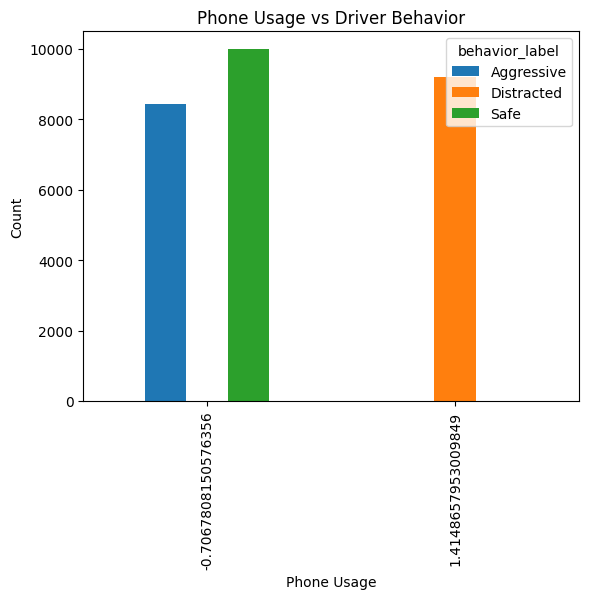

In [23]:
pd.crosstab(df.phone_usage, df.behavior_label).plot(kind='bar')

plt.title("Phone Usage vs Driver Behavior")

plt.xlabel("Phone Usage")

plt.ylabel("Count")

plt.show()


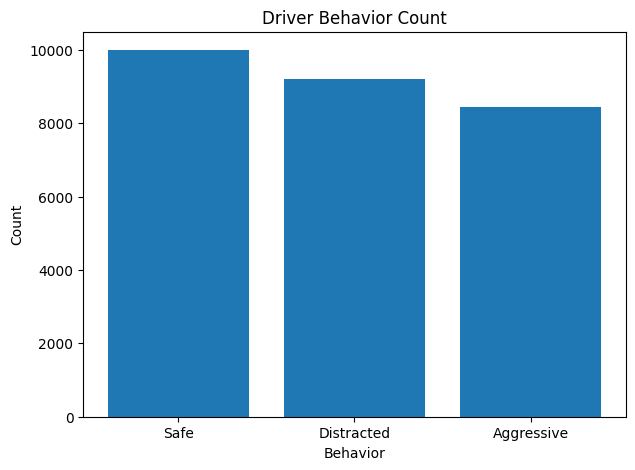

In [25]:
behavior_counts = df['behavior_label'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(behavior_counts.index, behavior_counts.values)

plt.title("Driver Behavior Count")

plt.xlabel("Behavior")

plt.ylabel("Count")

plt.show()

In [ ]:
subdf = df[[
    'speed_kmph',
    'accel_x',
    'accel_y',
    'brake_pressure',
    'steering_angle',
    'throttle',
    'lane_deviation',
    'phone_usage',
    'headway_distance',
    'reaction_time'
]]

print("\nSelected Features")
print(subdf.head())


Selected Features
   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle  throttle  \
0   -1.646197 -0.677689  1.264479       -0.605615       -0.333874 -0.029914   
1   -1.502903 -0.228698 -1.078528       -0.084025       -2.575153 -0.817606   
2    0.859157  2.502836  1.549250        1.526413       -0.643518  1.145865   
3    1.937781  1.275730 -1.096786        0.218909        1.891133  1.366293   
4   -0.455938 -1.433722  0.742446       -0.016311       -0.432609  0.361065   

   lane_deviation  phone_usage  headway_distance  reaction_time  
0        0.756130     1.414866         -0.503335       0.850947  
1        2.271441     1.414866          0.479102       0.912802  
2       -0.733058    -0.706781         -1.070117      -1.305385  
3        0.905243    -0.706781         -1.075191      -1.016568  
4        2.600000     1.414866         -0.175677       0.785500  


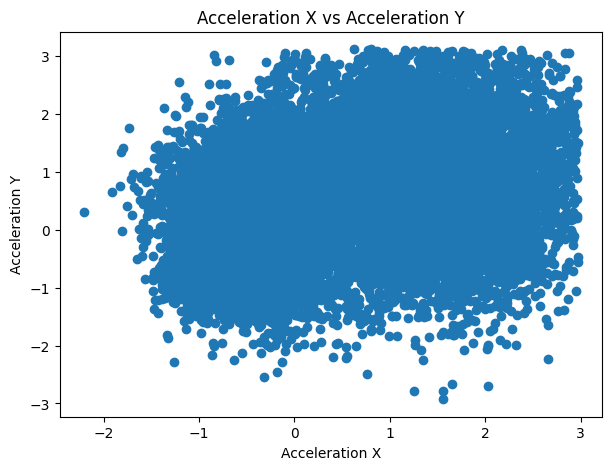

In [26]:
plt.figure(figsize=(7,5))

plt.scatter(df['accel_x'], df['accel_y'])

plt.title("Acceleration X vs Acceleration Y")

plt.xlabel("Acceleration X")

plt.ylabel("Acceleration Y")

plt.show()

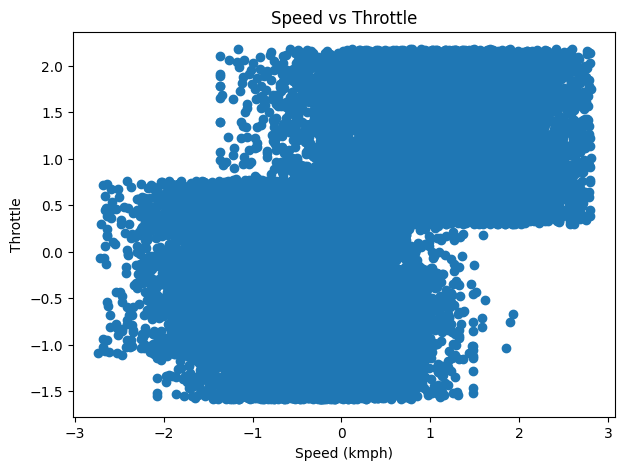

In [27]:
plt.figure(figsize=(7,5))

plt.scatter(df['speed_kmph'], df['throttle'])

plt.title("Speed vs Throttle")

plt.xlabel("Speed (kmph)")

plt.ylabel("Throttle")

plt.show()

In [ ]:
X = subdf

y = df['behavior_label_encoded']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.3,
    random_state=42
)

print("\nX_train Shape")
print(X_train.shape)

print("\nX_test Shape")
print(X_test.shape)


X_train Shape
(8296, 10)

X_test Shape
(19360, 10)


In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

print("\nModel Trained Successfully!")


Model Trained Successfully!


In [ ]:
predictions = model.predict(X_test)

print("\nPredictions")
print(predictions)


Predictions
[1 0 2 ... 1 0 2]


In [ ]:
accuracy = model.score(X_test, y_test)

print("\nModel Accuracy")
print(accuracy)



Model Accuracy
1.0


In [ ]:
sample_data = [[
    36.07,
    0.53,
    0.70,
    23.10,
    -3.16,
    53.12,
    0.85,
    1,
    17.99,
    1.40
]]

prediction = model.predict(sample_data)

print("\nPredicted Encoded Behavior")
print(prediction)


Predicted Encoded Behavior
[0]


c:\Users\rithi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
decoded_prediction = le.inverse_transform(prediction)

print("\nPredicted Driver Behavior")
print(decoded_prediction)


Predicted Driver Behavior
['Aggressive']
